## Оценка эффекта тестов
### Цель: измерить эффект каждой модели относительно контроля

Метрики для анализа:


*   orders_rub        - стоимость созданных товаров
*   sales_rub         - стоимость выкупленных товаров
*   created_items_cnt - количество заказанных товаров
*   spp_pct           - средний % СПП
*   supplier_price      - стоимость созданных товаров в цене продавца







In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
mde = pd.read_parquet('mde.parquet')
hom = pd.read_parquet('homogenuity.parquet')
res = pd.read_parquet('result.parquet')

print(f'mde.parquet:         {mde.shape[0]:>10,} строк × {mde.shape[1]} колонок')
print(f'homogenuity.parquet: {hom.shape[0]:>10,} строк × {hom.shape[1]} колонок')
print(f'result.parquet:      {res.shape[0]:>10,} строк × {res.shape[1]} колонок')

mde.parquet:          1,030,254 строк × 8 колонок
homogenuity.parquet:    571,116 строк × 23 колонок
result.parquet:       1,328,879 строк × 11 колонок


Отрицательные значения переменной spp_pct

In [4]:
neg_res = res[res['spp_pct'] < 0].copy()
print(f'Строк с spp_pct < 0:  {len(neg_res):>5,} ({len(neg_res)/len(res)*100:.3f}% от всех)')

Строк с spp_pct < 0:    900 (0.068% от всех)


Переменная spp_pct отражает средний % Скидки Постоянного Покупателя.

По определению скидка не может быть отрицательной, т.е. приводить к повышению цены, поэтому данные значения принято не использовать для дальнейшего анализа. Кроме того, процент таких значений относительного общего количества данных крайне мал, их удаление не должно значительно повлиять на результат исследования.

In [6]:
#Уберем строки с отрицательным spp_pct
res = res[res['spp_pct'] >= 0].copy()
print(f'После фильтрации: {res.shape[0]:>10,} строк × {res.shape[1]} колонок')

После фильтрации:  1,327,979 строк × 11 колонок


###Средние значения метрик для тестовых и контрольной группы

In [21]:
metrics = ['orders_rub', 'sales_rub', 'created_items_cnt', 'spp_pct', 'supplier_price']
group_means = res.groupby('grp')[metrics].mean()

#Найдем средние значения каждой метрики для каждой тестовой группы
test_groups = ['1prc_increase', '1prc_decrease',
               '3prc_increase', '3prc_decrease',
               '5prc_increase', '5prc_decrease']

test_means = group_means.loc[test_groups]

#Найдем средние значения каждой метрики для контрольной группы
control_means = group_means.loc['control']

print('\nСредние по тестовым группам:\n')
display(test_means)

print('Средние по контролю:\n')
display(control_means)


Средние по тестовым группам:



,orders_rub,sales_rub,created_items_cnt,spp_pct,supplier_price
grp,,,,,
1prc_increase,5436.670992,1391.388225,3.418801,0.274244,7251.194568
1prc_decrease,5385.428686,1390.331358,3.441014,0.288515,7326.776928
3prc_increase,5518.870551,1406.337140,3.405999,0.260958,7226.369198
3prc_decrease,5348.692496,1381.334835,3.471273,0.302299,7420.052701
5prc_increase,5605.429582,1418.568898,3.408186,0.247074,7205.790655
5prc_decrease,5228.633817,1362.677997,3.466670,0.316403,7401.731385


Средние по контролю:



,control
orders_rub,5452.578510
sales_rub,1394.432281
created_items_cnt,3.449299
spp_pct,0.281616
supplier_price,7345.092961


###Доверительный интервал

In [35]:
n_boot = 1000
alpha = 0.05

ci_rows = []

for metric in metrics:
    control_vals = res.loc[res['grp'] == 'control', metric].dropna().to_numpy()
    n_control = len(control_vals)

    for g in test_groups:
        test_vals = res.loc[res['grp'] == g, metric].dropna().to_numpy()
        n_test = len(test_vals)

        boot_diffs = np.empty(n_boot)
        for i in range(n_boot):
            boot_control = np.random.choice(control_vals, size=n_control, replace=True)
            boot_test = np.random.choice(test_vals, size=n_test, replace=True)
            boot_diffs[i] = boot_test.mean() - boot_control.mean()

        low, high = np.percentile(boot_diffs, [100*alpha/2, 100*(1-alpha/2)])

        ci_rows.append({
            'group': g,
            'metric': metric,
            'effect_mean': boot_diffs.mean(),
            'ci_low': low,
            'ci_high': high
        })

ci_df = pd.DataFrame(ci_rows)
display(ci_df)

,group,metric,effect_mean,ci_low,ci_high
0,1prc_increase,orders_rub,-15.919319,-56.256822,25.036263
1,1prc_decrease,orders_rub,-67.482904,-109.474618,-26.424974
2,3prc_increase,orders_rub,66.392959,25.341608,107.176261
3,3prc_decrease,orders_rub,-102.522191,-139.939831,-63.404082
4,5prc_increase,orders_rub,152.027830,110.684233,193.692913
5,5prc_decrease,orders_rub,-223.751539,-261.891811,-186.059026
6,1prc_increase,sales_rub,-3.012486,-13.203056,6.700215
7,1prc_decrease,sales_rub,-4.120546,-13.922464,5.389036
8,3prc_increase,sales_rub,11.763647,2.069653,21.531184
9,3prc_decrease,sales_rub,-12.966134,-23.184495,-2.174610


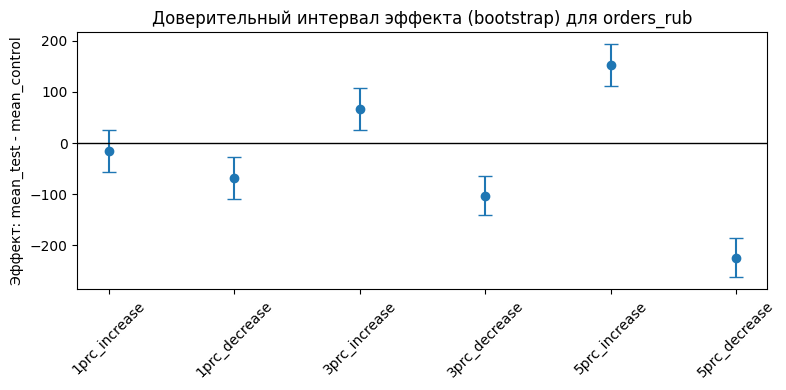

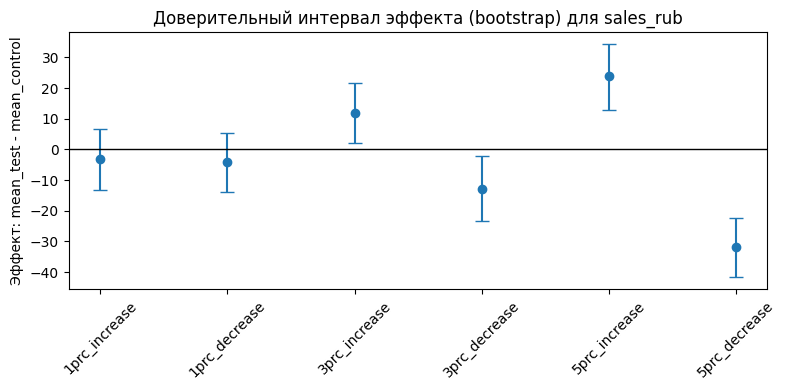

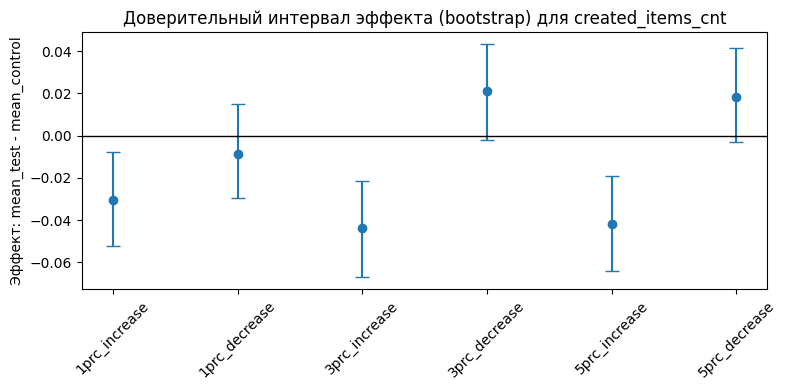

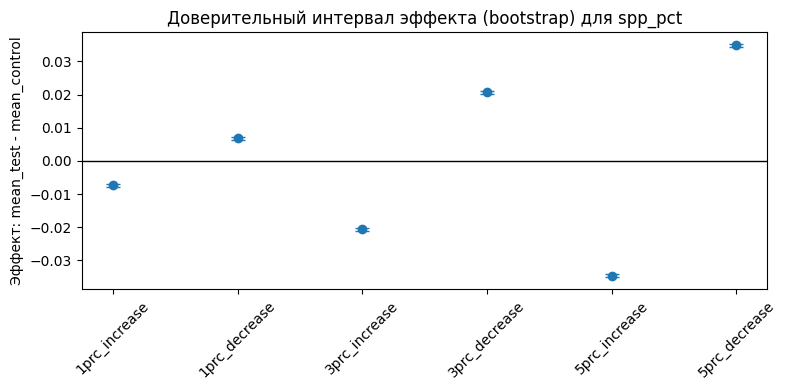

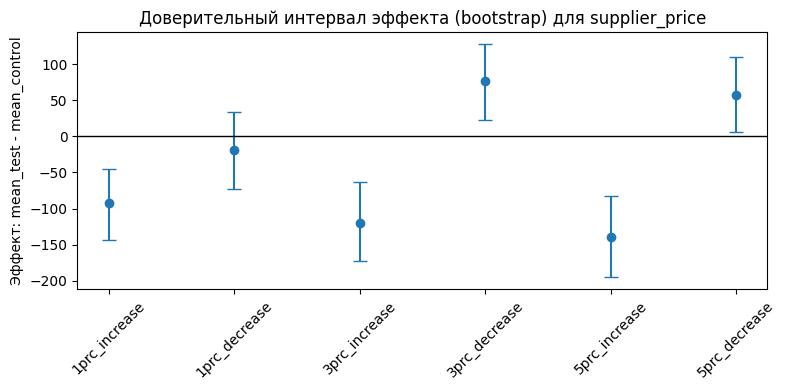

In [36]:
for metric in metrics:
    df_m = ci_df[ci_df['metric'] == metric].set_index('group').loc[test_groups]

    effects = df_m['effect_mean'].values
    lower = df_m['ci_low'].values
    upper = df_m['ci_high'].values

    x = np.arange(len(test_groups))
    yerr = np.vstack([effects - lower, upper - effects])

    plt.figure(figsize=(8, 4))
    plt.errorbar(x, effects, yerr=yerr, fmt='o', capsize=5)
    plt.axhline(0, color='black', linewidth=1)
    plt.xticks(x, test_groups, rotation=45)
    plt.ylabel('Эффект: mean_test - mean_control')
    plt.title(f'Доверительный интервал эффекта (bootstrap) для {metric}')
    plt.tight_layout()
    plt.show()

### Абсолютный эффект: mean_test - mean_control

In [22]:
abs_effect = group_means.loc[test_groups].subtract(control_means)
display(abs_effect)

,orders_rub,sales_rub,created_items_cnt,spp_pct,supplier_price
grp,,,,,
1prc_increase,-15.907517,-3.044055,-0.030498,-0.007372,-93.898393
1prc_decrease,-67.149823,-4.100922,-0.008285,0.006899,-18.316033
3prc_increase,66.292042,11.904859,-0.043300,-0.020658,-118.723763
3prc_decrease,-103.886013,-13.097446,0.021974,0.020683,74.959740
5prc_increase,152.851072,24.136617,-0.041113,-0.034542,-139.302306
5prc_decrease,-223.944692,-31.754284,0.017371,0.034787,56.638424


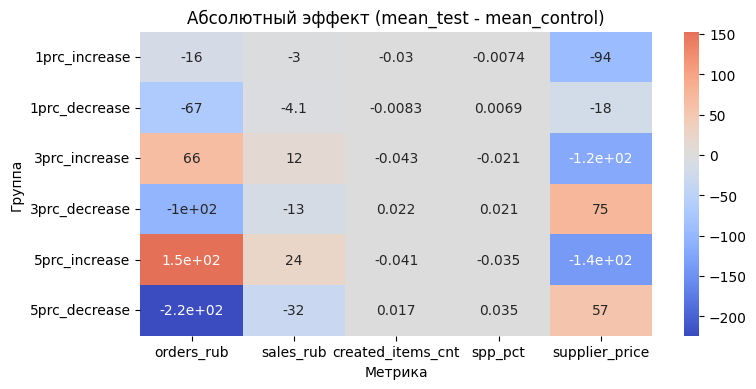

In [24]:
#Отобразим полученные результаты на тепловой карте
plt.figure(figsize=(8, 4))
sns.heatmap(abs_effect[metrics], annot=True, cmap='coolwarm', center=0)
plt.title('Абсолютный эффект (mean_test - mean_control)')
plt.ylabel('Группа')
plt.xlabel('Метрика')
plt.tight_layout()
plt.show()

### Относительный эффект: (mean_test - mean_control) / mean_control * 100%


In [25]:
rel_effect = abs_effect[metrics].div(control_means) * 100
display(rel_effect)

,orders_rub,sales_rub,created_items_cnt,spp_pct,supplier_price
grp,,,,,
1prc_increase,-0.291743,-0.218301,-0.884176,-2.617803,-1.278383
1prc_decrease,-1.231524,-0.294093,-0.240205,2.449911,-0.249364
3prc_increase,1.215793,0.853742,-1.255332,-7.335579,-1.616368
3prc_decrease,-1.905264,-0.939267,0.637043,7.344351,1.020542
5prc_increase,2.803281,1.730928,-1.191938,-12.265535,-1.896536
5prc_decrease,-4.107134,-2.277220,0.503598,12.352673,0.771106


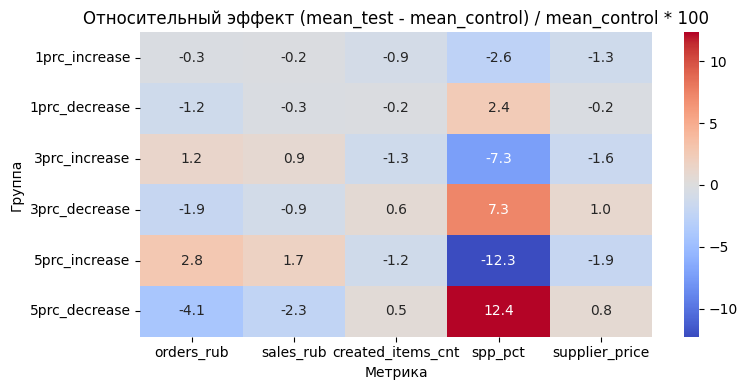

In [27]:
plt.figure(figsize=(8, 4))
sns.heatmap(rel_effect, annot=True, fmt='.1f',
            cmap='coolwarm', center=0)
plt.title('Относительный эффект (mean_test - mean_control) / mean_control * 100')
plt.ylabel('Группа')
plt.xlabel('Метрика')
plt.tight_layout()
plt.show()

### Статистический тест Манна-Уитни (эффект значим при p-value <0.05)

В тесте Манна–Уитни формулируется нулевая гипотеза: распределения в контрольной и тестовой группе одинаковы, реального эффекта нет.

 Если p-value меньше выбранного порога, мы говорим, что результат статистически значим и отвергаем нулевую гипотезу.

In [29]:
from scipy.stats import mannwhitneyu

results = []

for metric in metrics:
    control_vals = res.loc[res['grp'] == 'control', metric].dropna()
    for g in test_groups:
        test_vals = res.loc[res['grp'] == g, metric].dropna()
        stat, p = mannwhitneyu(control_vals, test_vals, alternative='two-sided')
        results.append({
            'group': g,
            'metric': metric,
            'u_stat': stat,
            'p_value': p
        })

mw_df = pd.DataFrame(results)
display(mw_df)

,group,metric,u_stat,p_value
0,1prc_increase,orders_rub,1.770934e+10,6.461038e-01
1,1prc_decrease,orders_rub,1.827446e+10,1.131234e-02
2,3prc_increase,orders_rub,1.719645e+10,1.904110e-07
3,3prc_decrease,orders_rub,1.882431e+10,8.591772e-10
4,5prc_increase,orders_rub,1.660671e+10,8.083040e-22
5,5prc_decrease,orders_rub,1.957437e+10,2.089484e-39
6,1prc_increase,sales_rub,1.770967e+10,6.470823e-01
7,1prc_decrease,sales_rub,1.819178e+10,9.177133e-01
8,3prc_increase,sales_rub,1.729718e+10,2.909500e-02
9,3prc_decrease,sales_rub,1.868402e+10,3.435591e-02


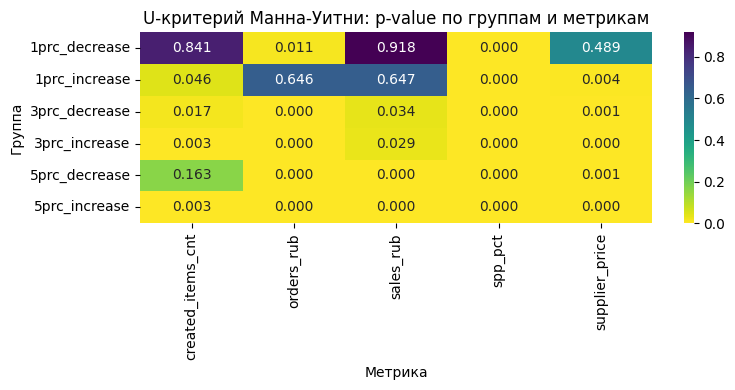

In [33]:
p_matrix = mw_df.pivot(index='group', columns='metric', values='p_value')

plt.figure(figsize=(8, 4))
sns.heatmap(p_matrix, annot=True, fmt='.3f',
            cmap='viridis_r')
plt.title('U-критерий Манна-Уитни: p-value по группам и метрикам')
plt.ylabel('Группа')
plt.xlabel('Метрика')
plt.tight_layout()
plt.show()

По результатам критерия Манна–Уитни большинство тестовых групп по ключевым метрикам статистически значимо отличаются от контрольной группы. Это означает, что наблюдаемые различия с высокой вероятностью не являются результатом случайных колебаний, а отражают реальное влияние изменения цены. Наиболее устойчивые и значимые отличия наблюдаются при изменениях цены на 3–5 п.п., тогда как часть эффектов для ±1 п.п. по отдельным метрикам может быть статистически незначимой.

###Сводная таблица

In [62]:
import numpy as np
import pandas as pd

metrics = ['orders_rub', 'sales_rub', 'created_items_cnt', 'spp_pct', 'supplier_price']
test_groups = ['1prc_increase', '1prc_decrease',
               '3prc_increase', '3prc_decrease',
               '5prc_increase', '5prc_decrease']

mean_rows = []
for g in test_groups:
    for m in metrics:
        mean_rows.append({
            'group': g,
            'metric': m,
            'mean_value': test_means.loc[g, m]
        })
mean_df = pd.DataFrame(mean_rows)

ci_short = ci_df[['group', 'metric', 'ci_low', 'ci_high']].copy()

abs_df = (abs_effect
          .loc[test_groups, metrics]
          .reset_index())
abs_df = abs_df.rename(columns={abs_df.columns[0]: 'group'})
abs_df = abs_df.melt(id_vars='group', var_name='metric', value_name='abs_effect')

rel_df = (rel_effect
          .loc[test_groups, metrics]
          .reset_index())
rel_df = rel_df.rename(columns={rel_df.columns[0]: 'group'})
rel_df = rel_df.melt(id_vars='group', var_name='metric', value_name='rel_effect')

mw_short = mw_df[['group', 'metric', 'p_value']].copy()

summary = (mean_df
           .merge(ci_short, on=['group', 'metric'], how='left')
           .merge(abs_df, on=['group', 'metric'], how='left')
           .merge(rel_df, on=['group', 'metric'], how='left')
           .merge(mw_short, on=['group', 'metric'], how='left'))

summary = (summary
           .set_index(['group', 'metric'])
           .loc[test_groups]
           .sort_index(level=1))

summary = (summary
           .sort_index(level=['group', 'metric']))

summary = summary.loc[test_groups]

display(summary)

mean_value      ci_low     ci_high  \
group         metric                                                   
1prc_increase created_items_cnt     3.418801   -0.052218   -0.007513   
              orders_rub         5436.670992  -56.256822   25.036263   
              sales_rub          1391.388225  -13.203056    6.700215   
              spp_pct               0.274244   -0.007842   -0.006912   
              supplier_price     7251.194568 -143.567891  -44.683883   
1prc_decrease created_items_cnt     3.441014   -0.029550    0.015027   
              orders_rub         5385.428686 -109.474618  -26.424974   
              sales_rub          1390.331358  -13.922464    5.389036   
              spp_pct               0.288515    0.006401    0.007316   
              supplier_price     7326.776928  -72.591325   33.279521   
3prc_increase created_items_cnt     3.405999   -0.066951   -0.021308   
              orders_rub         5518.870551   25.341608  107.176261   
              sales_rub          1406.337140    2.069653   21.531184   
              spp_pct               0.260958   -0.021152   -0.020196   
              supplier_price     7226.369198 -173.051974  -62.990319   
3prc_decrease created_items_cnt     3.471273   -0.001979    0.043407   
              orders_rub         5348.692496 -139.939831  -63.404082   
              sales_rub          1381.334835  -23.184495   -2.174610   
              spp_pct               0.302299    0.020206    0.021135   
              supplier_price     7420.052701   22.947578  127.701206   
5prc_increase created_items_cnt     3.408186   -0.064102   -0.019224   
              orders_rub         5605.429582  110.684233  193.692913   
              sales_rub          1418.568898   12.896495   34.364304   
              spp_pct               0.247074   -0.035017   -0.034069   
              supplier_price     7205.790655 -194.931787  -82.180552   
5prc_decrease created_items_cnt     3.466670   -0.003032    0.041565   
              orders_rub         5228.633817 -261.891811 -186.059026   
              sales_rub          1362.677997  -41.615670  -22.418176   
              spp_pct               0.316403    0.034364    0.035225   
              supplier_price     7401.731385    5.843190  109.975424   

                                 abs_effect  rel_effect        p_value  
group         metric                                                    
1prc_increase created_items_cnt   -0.030498   -0.884176   4.629879e-02  
              orders_rub         -15.907517   -0.291743   6.461038e-01  
              sales_rub           -3.044055   -0.218301   6.470823e-01  
              spp_pct             -0.007372   -2.617803  3.212129e-216  
              supplier_price     -93.898393   -1.278383   3.586337e-03  
1prc_decrease created_items_cnt   -0.008285   -0.240205   8.406017e-01  
              orders_rub         -67.149823   -1.231524   1.131234e-02  
              sales_rub           -4.100922   -0.294093   9.177133e-01  
              spp_pct              0.006899    2.449911  2.871735e-195  
              supplier_price     -18.316033   -0.249364   4.892856e-01  
3prc_increase created_items_cnt   -0.043300   -1.255332   3.469576e-03  
              orders_rub          66.292042    1.215793   1.904110e-07  
              sales_rub           11.904859    0.853742   2.909500e-02  
              spp_pct             -0.020658   -7.335579   0.000000e+00  
              supplier_price    -118.723763   -1.616368   5.354776e-05  
3prc_decrease created_items_cnt    0.021974    0.637043   1.711932e-02  
              orders_rub        -103.886013   -1.905264   8.591772e-10  
              sales_rub          -13.097446   -0.939267   3.435591e-02  
              spp_pct              0.020683    7.344351   0.000000e+00  
              supplier_price      74.959740    1.020542   5.465553e-04  
5prc_increase created_items_cnt   -0.041113   -1.191938   3.126632e-03  
              orders_rub         152.851072    2.8